In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = kagglehub.dataset_download("shivamb/netflix-shows")
path

Using Colab cache for faster access to the 'netflix-shows' dataset.


'/kaggle/input/netflix-shows'

In [ ]:
df = pd.read_csv(f"{path}/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# DATA ENGINEERING PIPELINE

In [ ]:
# spliting the duration into the numerical part by min ans seasons
df['duration_split'] =df['duration'].str.split()
df['duration_split']

,duration_split
0,"[90, min]"
1,"[2, Seasons]"
2,"[1, Season]"
3,"[1, Season]"
4,"[2, Seasons]"
...,...
8802,"[158, min]"
8803,"[2, Seasons]"
8804,"[88, min]"
8805,"[88, min]"


In [ ]:
#filling missing values with unknown

df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')
df['duration'] = df['duration'].fillna('unknown')
df['rating'] = df['rating'].fillna('Not rated')

##### Duration Fix

In [ ]:
# converting the data type in float
df['duration_num'] = df['duration_split'].str[0].astype(float)

In [ ]:
# seprating movie's duration and TV Show's seasons
df['movie_duration_min'] = df['duration_num'].where(df['type'] == 'Movie')
df['TV_show_seasons'] =df['duration_num'].where(df['type'] == 'TV Show')


In [ ]:
# Validation
assert df['movie_duration_min'].notna().equals((df['type'] == 'Movie') & df['duration_num'].notna()), "Mismatch: movie durations don't align with Movie rows or have unexpected NaNs"
assert df['TV_show_seasons'].notna().equals((df['type'] == 'TV Show') & df['duration_num'].notna()), "Mismatch: season counts don't align with TV Show rows or have unexpected NaNs"

print("Duration split validated successfully.")

Duration split validated successfully.


In [ ]:
df['country'].value_counts()

,count
country,
United States,2818
India,972
unknown,831
United Kingdom,419
Japan,245
...,...
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1


##### Unnesting Array

In [ ]:
# striping by column and striping the extra spaces
for col in ['cast','director', 'country', 'listed_in']:
    df[f'{col}_list'] = df[col].str.split(',').apply(lambda x: [item.strip() for item in x] if isinstance(x, list) else x)

In [ ]:
cast_exploded = df.explode('cast_list')
director_exploded = df.explode('director_list')
country_exploded = df.explode('country_list')
genre_exploded = df.explode('listed_in_list')

In [ ]:
top_10_country = country_exploded[country_exploded['country_list'] !='unknown']['country_list'].value_counts().head(10)
top_10_country

,count
country_list,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


In [ ]:
top_10_genre = genre_exploded['listed_in_list'].value_counts().head(10)
top_10_genre

,count
listed_in_list,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [ ]:
top_10_actors = cast_exploded[cast_exploded['cast_list'] != 'unknown']['cast_list'].value_counts().head(10).sort_values(ascending=False)
top_10_actors

,count
cast_list,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


In [ ]:
top_10_directors = director_exploded[director_exploded['director_list'] != 'unknown']['director_list'].value_counts().head(10)
top_10_directors

,count
director_list,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


#### Datetime  parsing

In [ ]:

df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['day_of_week_added'] = df['date_added'].dt.day_name()

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,duration_num,movie_duration_min,TV_show_seasons,cast_list,director_list,country_list,listed_in_list,year_added,month_added,day_of_week_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,...,90.0,90.0,NaN,[unknown],[Kirsten Johnson],[United States],[Documentaries],2021.0,September,Saturday
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,2.0,NaN,2.0,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...",[unknown],[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]",2021.0,September,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,...,1.0,NaN,1.0,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...",[Julien Leclercq],[unknown],"[Crime TV Shows, International TV Shows, TV Ac...",2021.0,September,Friday
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,...,1.0,NaN,1.0,[unknown],[unknown],[unknown],"[Docuseries, Reality TV]",2021.0,September,Friday
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,2.0,NaN,2.0,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...",[unknown],[India],"[International TV Shows, Romantic TV Shows, TV...",2021.0,September,Friday


#### Some cleaning up

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
# replacing some misplace data with not rated
df['rating'] = df['rating'].replace({'74 min' : 'Not rated', '84 min' : 'Not rated' , '66 min' : 'Not rated'})
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
df.describe()

,date_added,release_year,duration_num,movie_duration_min,TV_show_seasons,year_added
count,8797,8807.000000,8804.000000,6128.000000,2676.000000,8797.000000
mean,2019-05-17 05:59:08.436967168,2014.180198,69.846888,99.577187,1.764948,2018.871888
min,2008-01-01 00:00:00,1925.000000,1.000000,3.000000,1.000000,2008.000000
25%,2018-04-06 00:00:00,2013.000000,2.000000,87.000000,1.000000,2018.000000
50%,2019-07-02 00:00:00,2017.000000,88.000000,98.000000,1.000000,2019.000000
75%,2020-08-19 00:00:00,2019.000000,106.000000,114.000000,2.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,312.000000,312.000000,17.000000,2021.000000
std,NaN,8.819312,50.814828,28.290593,1.582752,1.574243


##### THE VISUALIZATION

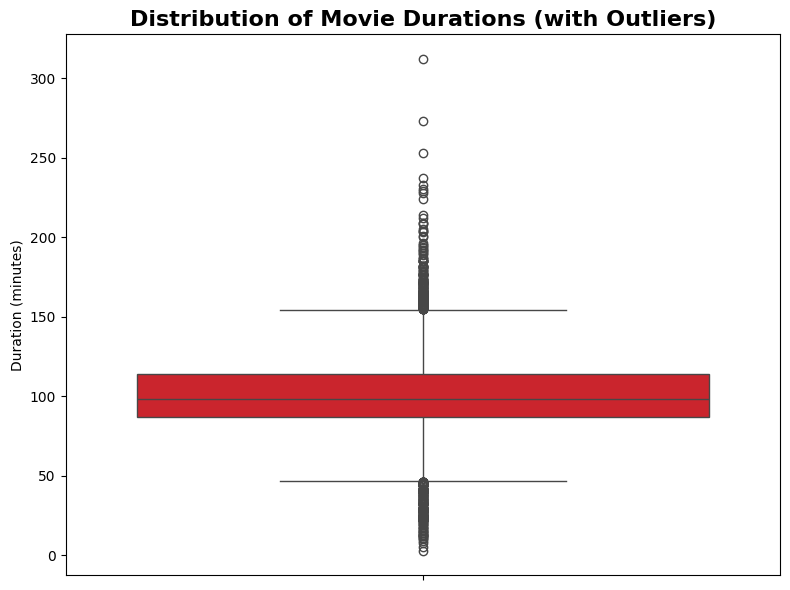

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['movie_duration_min'], color='#E50914')
plt.title('Distribution of Movie Durations (with Outliers)', fontsize=16, fontweight='bold')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

#### Temporal Trends

<Axes: xlabel='type', ylabel='count'>

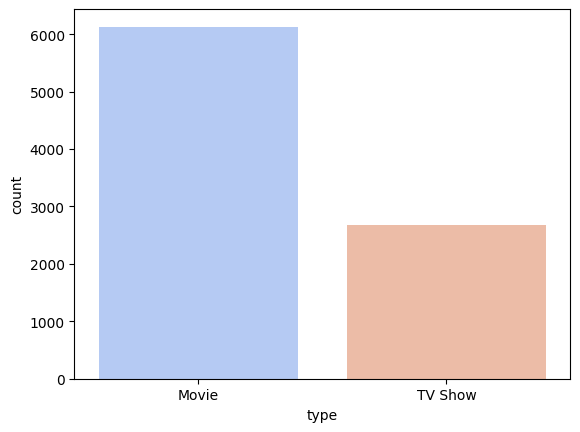

In [ ]:
sns.countplot(x= 'type' , data = df, palette='coolwarm', hue = 'type', legend=False)

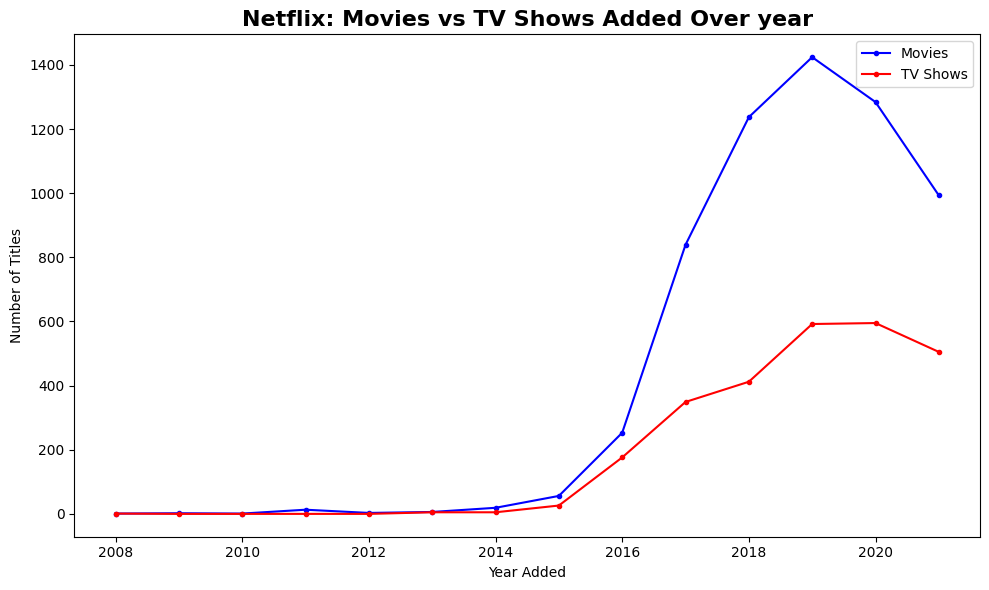

In [ ]:
years_list = sorted(df['year_added'].unique())


movie_counts = []
tv_shows_counts = []


for year in years_list:
    movies_this_year = df[(df['year_added'] == year) & (df['type'] == 'Movie')]
    tv_shows_this_year = df[(df['year_added'] == year) & (df['type'] == 'TV Show')]

    movie_counts.append(len(movies_this_year))
    tv_shows_counts.append(len(tv_shows_this_year))

plt.figure(figsize=(10, 6))
plt.title('Netflix: Movies vs TV Shows Added Over year', fontsize=16, fontweight='bold')

plt.plot(years_list, movie_counts, 'b.-', label='Movies')
plt.plot(years_list, tv_shows_counts, 'r.-', label='TV Shows')




plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend()
plt.tight_layout()
plt.show()

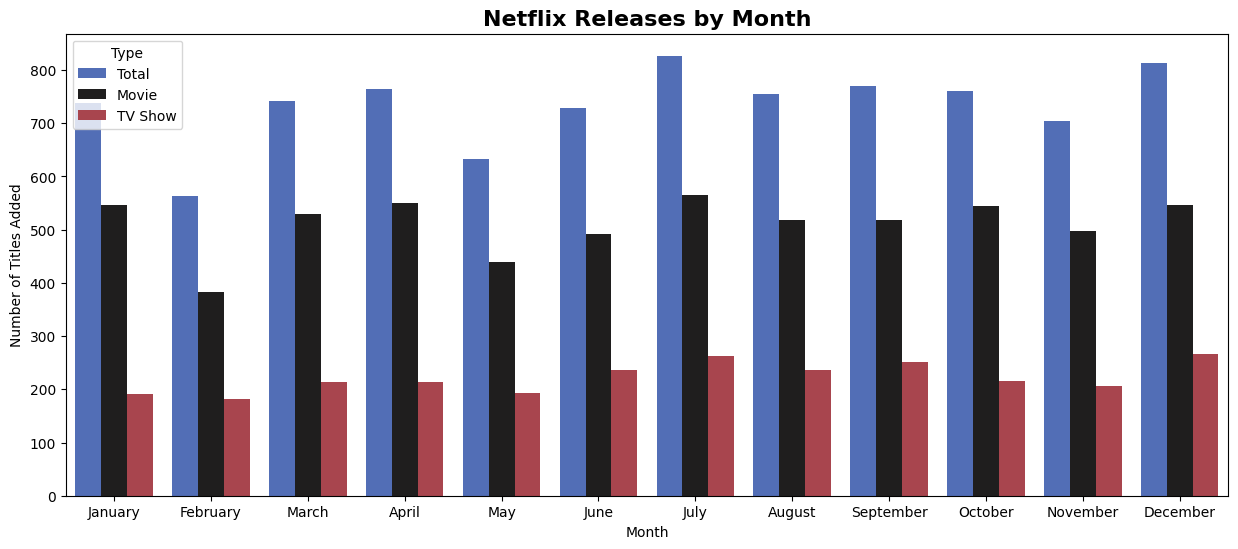

In [ ]:
plt.figure(figsize=(15,6))
plt.title('Netflix Releases by Month', fontdict={'fontweight': 'bold', 'fontsize': 16})

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']


df_total_copy = df.copy()
df_total_copy['type'] = 'Total'

df_for_this_plot = pd.concat([df, df_total_copy], ignore_index=True)

sns.countplot(x='month_added', data=df_for_this_plot, palette='icefire',hue='type', hue_order=['Total', 'Movie','TV Show'], order=month_order)
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type', loc='upper left')

plt.show()

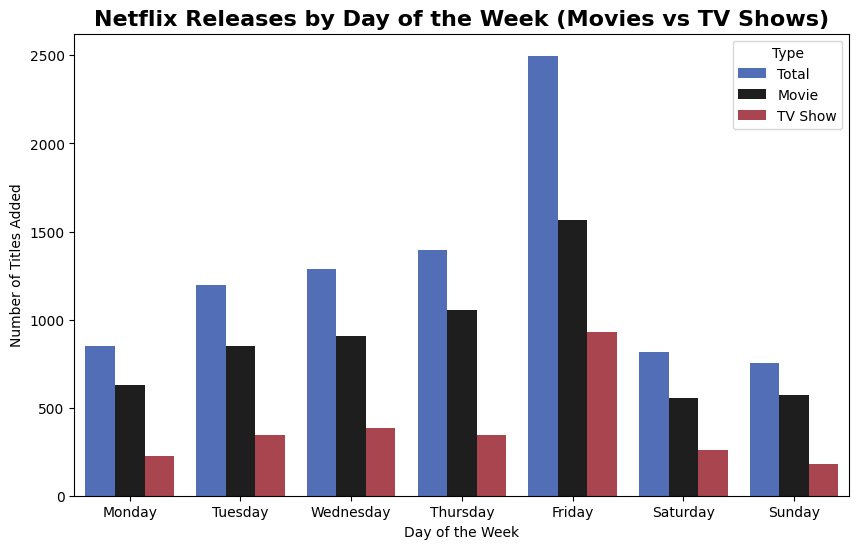

In [ ]:
# Bargraph for releases by Day

plt.figure(figsize=(10, 6))
plt.title('Netflix Releases by Day of the Week (Movies vs TV Shows)',fontdict={'fontweight': 'bold', 'fontsize': 16})

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']



sns.countplot(x='day_of_week_added',data= df_for_this_plot ,hue='type', hue_order = ['Total', 'Movie' ,'TV Show' ] , palette='icefire' , order = day_order)


plt.xlabel('Day of the Week')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type')

plt.show()

In [ ]:
years_list = sorted(df['year_added'].dropna().unique())
same_year_counts = []
total_count = []

for year in years_list:
    this_year_data = df[df['year_added'] == year]
    same_year_titles = len(this_year_data[this_year_data['release_year'] == year])

    same_year_counts.append(same_year_titles)
    total_count.append(len(this_year_data))

print(years_list)
print(same_year_counts)

[np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0)]
[0, 1, 0, 0, 1, 7, 16, 52, 189, 381, 561, 667, 777, 589]


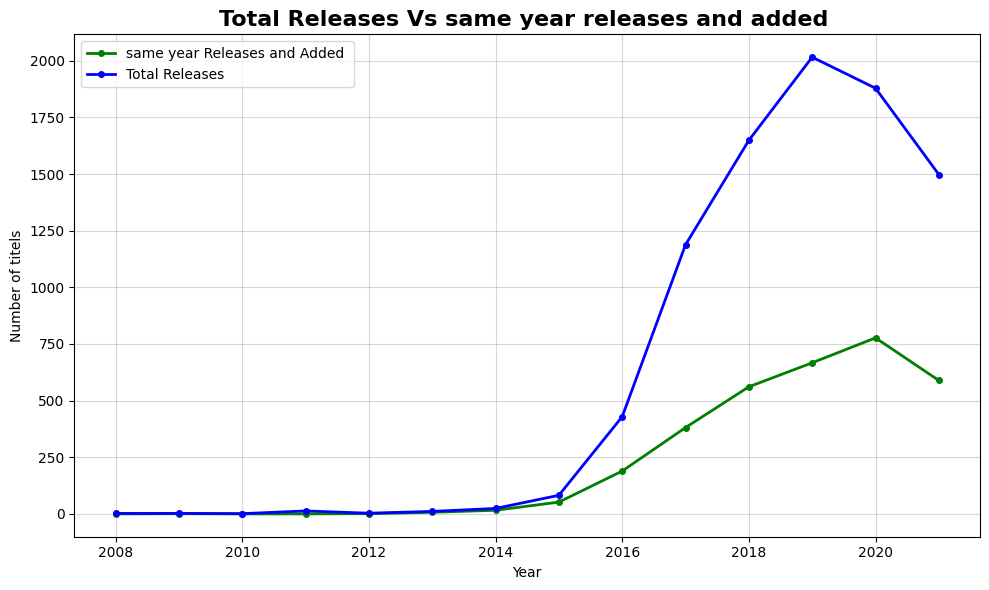

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Total Releases Vs same year releases and added ', fontsize=16, fontweight='bold')

plt.plot(years_list, same_year_counts, 'g.-', linewidth=2, markersize=8 , label='same year Releases and Added ')
plt.plot(years_list, total_count, 'b.-', linewidth=2, markersize=8 , label='Total Releases')



plt.xlabel('Year')
plt.ylabel('Number of titels')
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

#### Network & Geospatial Analysis

In [ ]:
pair_counts = {} # dict to store the pair

for countries in df['country_list']:
      if len(countries) > 1:
        for i in range(len(countries)):
            for j in range(len(countries)):
                if i != j:
                    country_a = countries[i]
                    country_b = countries[j]
                    pair_key = country_a + " - " + country_b

                    if pair_key in pair_counts:
                        pair_counts[pair_key] = pair_counts[pair_key] + 1
                    else:
                        pair_counts[pair_key] = 1


In [176]:
country_totals = {}
for countries in df['country_list']:
    for country in countries:
        if country in country_totals:
            country_totals[country] = country_totals[country] + 1
        else:
            country_totals[country] = 1

sorted_countries = sorted(country_totals.items(), key=lambda x: x[1], reverse=True)
top_countries = [country for country, count in sorted_countries[:10]]

print(top_countries)

['United States', 'India', 'unknown', 'United Kingdom', 'Canada', 'France', 'Japan', 'Spain', 'South Korea', 'Germany']


In [177]:
grid = pd.DataFrame(0, index=top_countries, columns=top_countries)

for country_a in top_countries:
    for country_b in top_countries:
        key = country_a + " - " + country_b
        if key in pair_counts:
            grid.loc[country_a, country_b] = pair_counts[key]

print(grid)

                United States  India  unknown  United Kingdom  Canada  France  \
United States               0     38        0             279     217     125   
India                      38      0        0              18       8       9   
unknown                     0      0        0               0       0       0   
United Kingdom            279     18        0               0      58      67   
Canada                    217      8        0              58       0      35   
France                    125      9        0              67      35       0   
Japan                      63      3        0              13      10      19   
Spain                      32      1        0              16      12      22   
South Korea                22      2        0               3       3       4   
Germany                    88      5        0              52      21      41   

                Japan  Spain  South Korea  Germany  
United States      63     32           22       88  
In

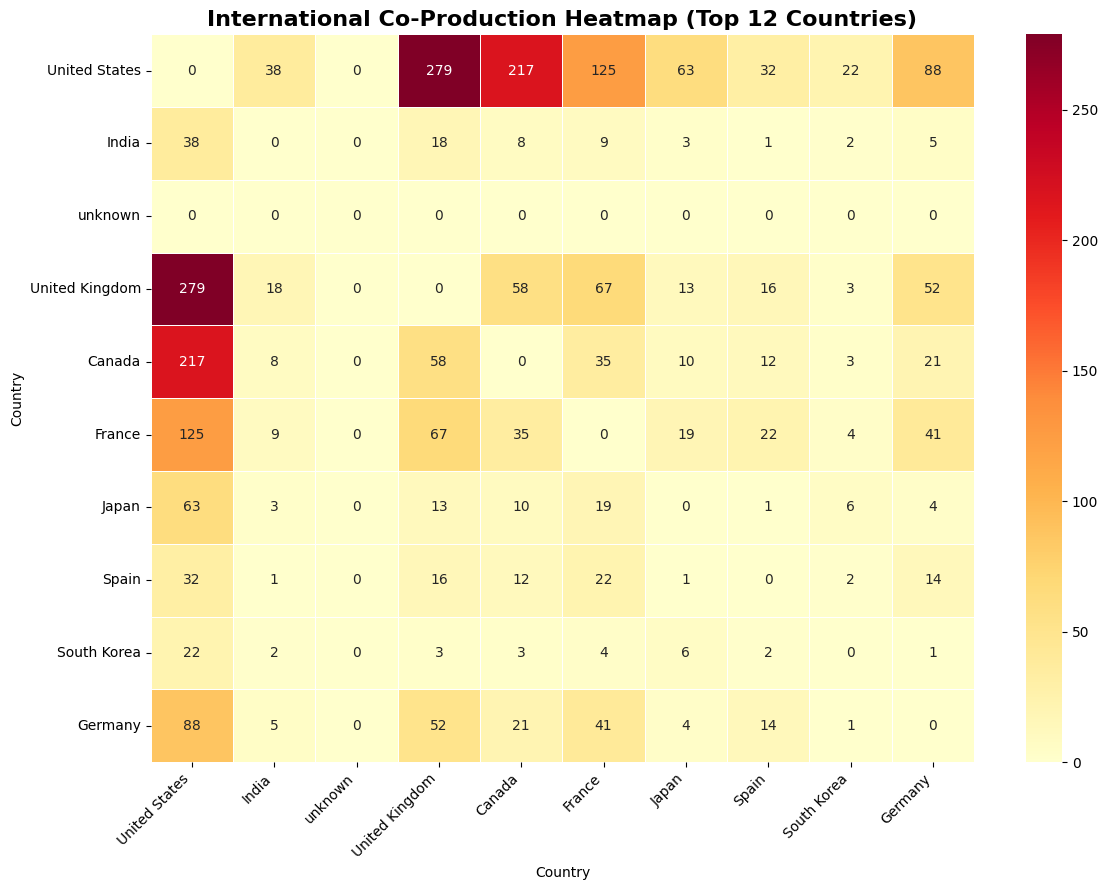

In [178]:
plt.figure(figsize=(12, 9))
plt.title('International Co-Production Heatmap (Top 12 Countries)', fontsize=16, fontweight='bold')

sns.heatmap(grid, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)

plt.xlabel('Country')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Top Cast,Directors , Country, Genre plot

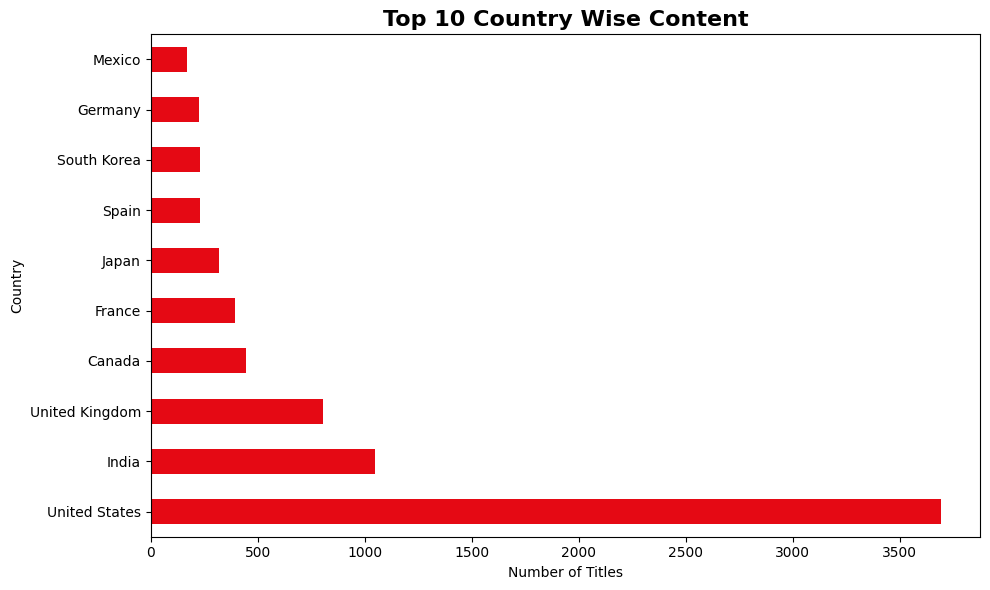

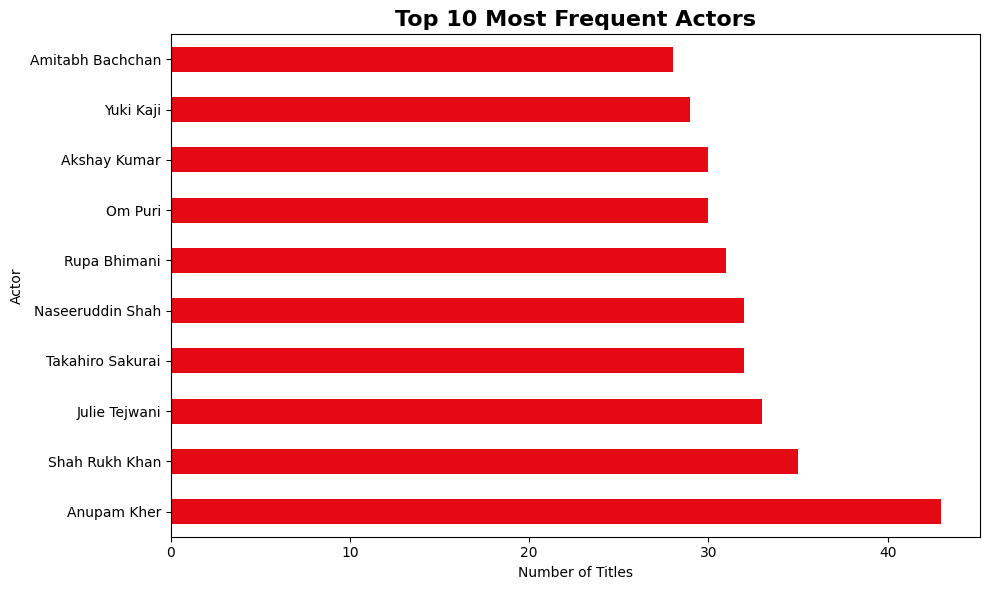

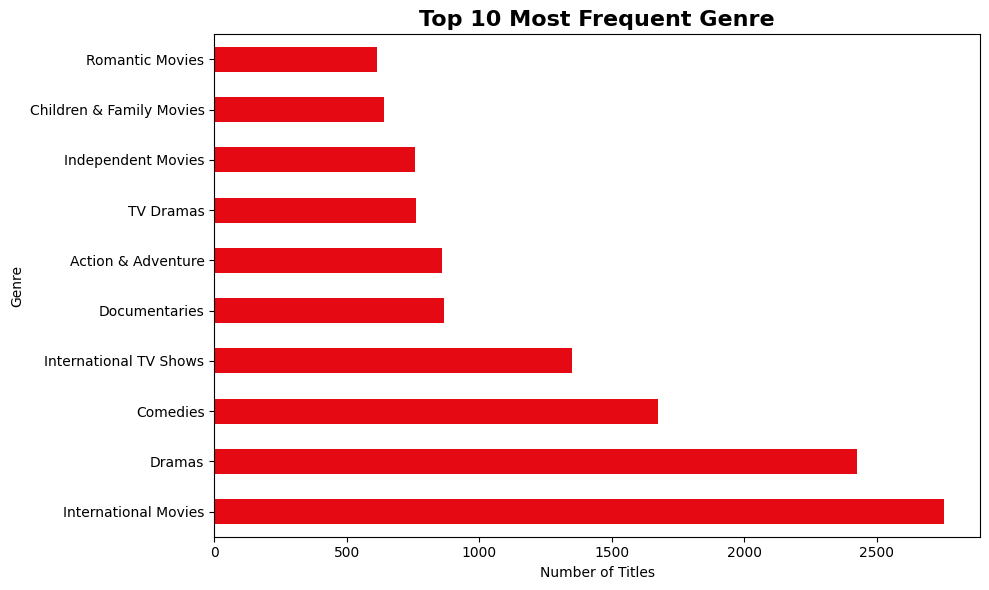

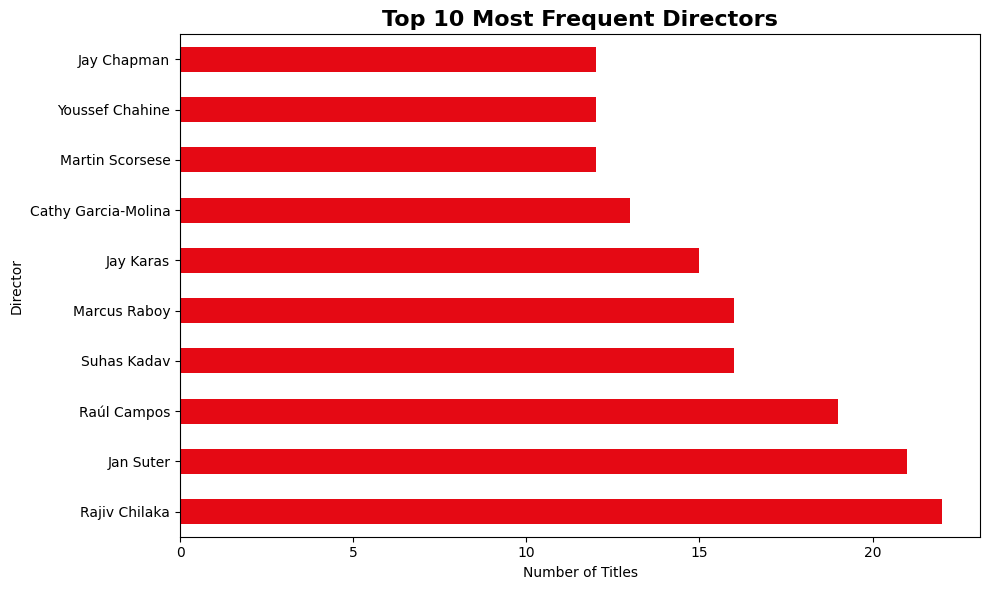

In [ ]:
# repeatative code ,  so defining a function

def plot_top10(series, title, xlabel, ylabel, color='#E50914'):
    plt.figure(figsize=(10, 6))
    series.plot(kind='barh', color=color)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


plot_top10(top_10_country, 'Top 10 Country Wise Content', 'Number of Titles', 'Country')
plot_top10(top_10_actors, 'Top 10 Most Frequent Actors', 'Number of Titles', 'Actor')
plot_top10(top_10_genre, 'Top 10 Most Frequent Genre', 'Number of Titles', 'Genre')
plot_top10(top_10_directors, 'Top 10 Most Frequent Directors', 'Number of Titles', 'Director')

#### Actors with director Analytics

In [ ]:
duo_counts = {}

for index, row in df.iterrows():
    actors = row['cast_list']
    directors = row['director_list']

    # skiping rows having unknown actors and directors
    if actors == ['unknown'] or directors == ['unknown']:
        continue

    for actor in actors:
        for director in directors:
            duo_key = actor + " with " + director

            if duo_key in duo_counts:
                duo_counts[duo_key] = duo_counts[duo_key] + 1
            else:
                duo_counts[duo_key] = 1

sorted_duos = sorted(duo_counts.items(), key=lambda x: x[1], reverse=True)
top_duos = sorted_duos[:10]

for duo, count in top_duos:
    print(f"{duo}: {count} titles")

Julie Tejwani with Rajiv Chilaka: 19 titles
Rajesh Kava with Rajiv Chilaka: 19 titles
Rupa Bhimani with Rajiv Chilaka: 18 titles
Jigna Bhardwaj with Rajiv Chilaka: 18 titles
Vatsal Dubey with Rajiv Chilaka: 16 titles
Mousam with Rajiv Chilaka: 13 titles
Swapnil with Rajiv Chilaka: 13 titles
Saurav Chakraborty with Suhas Kadav: 8 titles
Kappei Yamaguchi with Toshiya Shinohara: 7 titles
Satsuki Yukino with Toshiya Shinohara: 7 titles


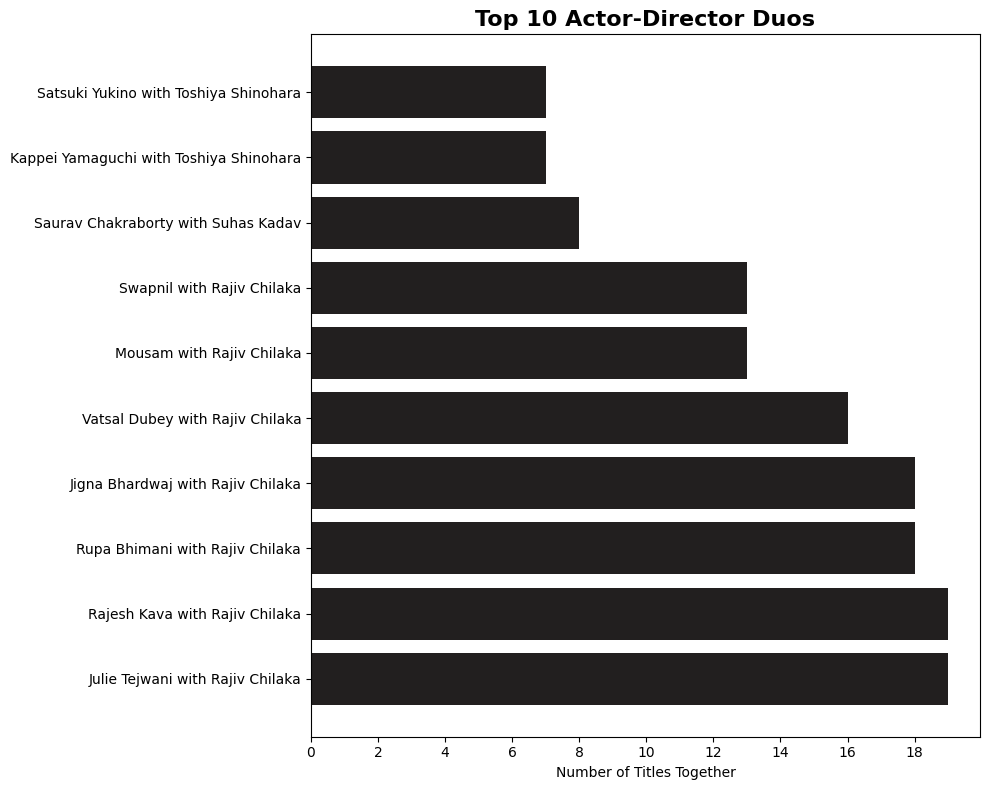

In [ ]:
labels = [duo for duo, count in top_duos]
values = [count for duo, count in top_duos]

plt.figure(figsize=(10, 8))
plt.barh(labels, values, color='#221f1f')
plt.title('Top 10 Actor-Director Duos', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles Together')



from matplotlib.ticker import MultipleLocator
plt.gca().xaxis.set_major_locator(MultipleLocator(2))


plt.tight_layout()
plt.show()

#### Genre distribution for top Actors , top Directors and for top Countries

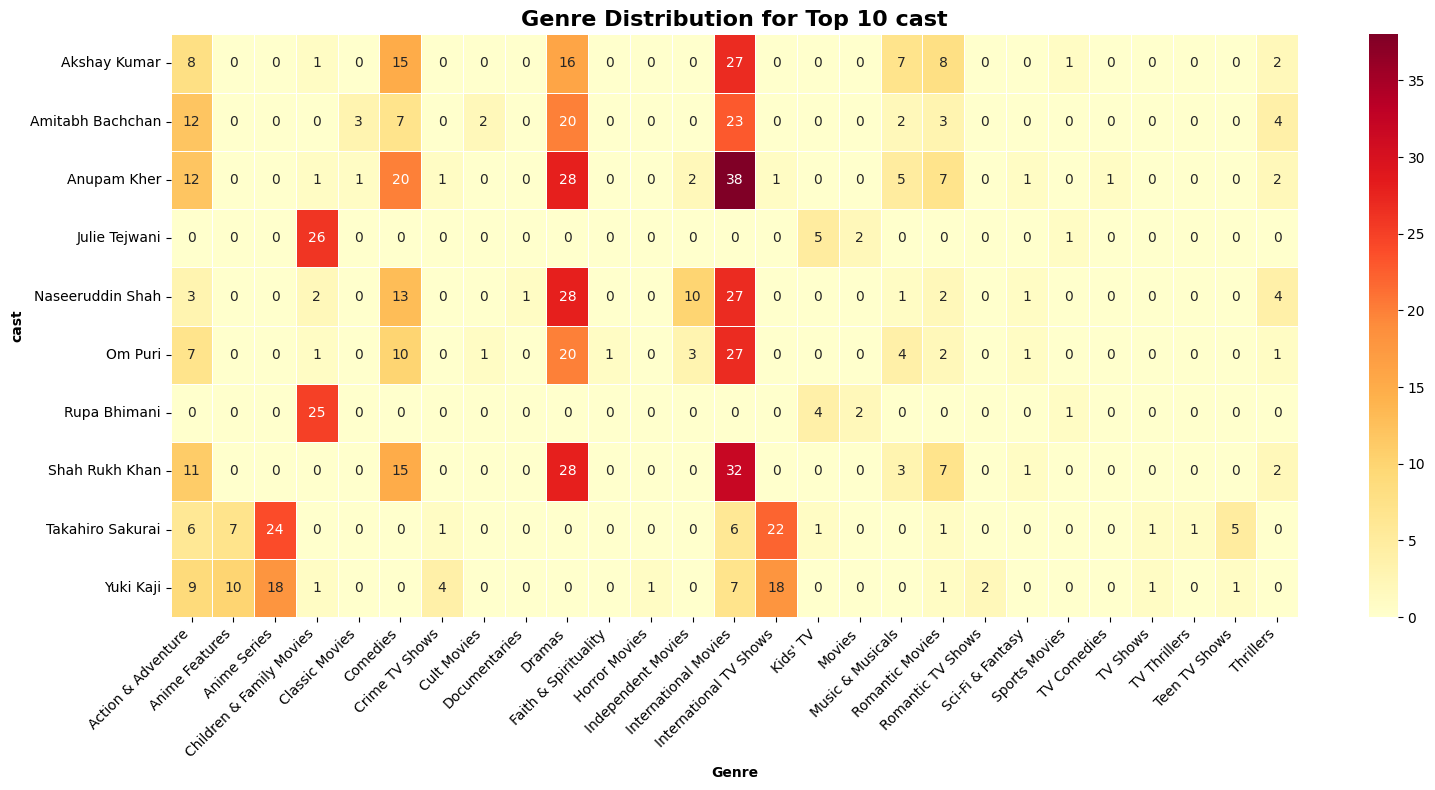

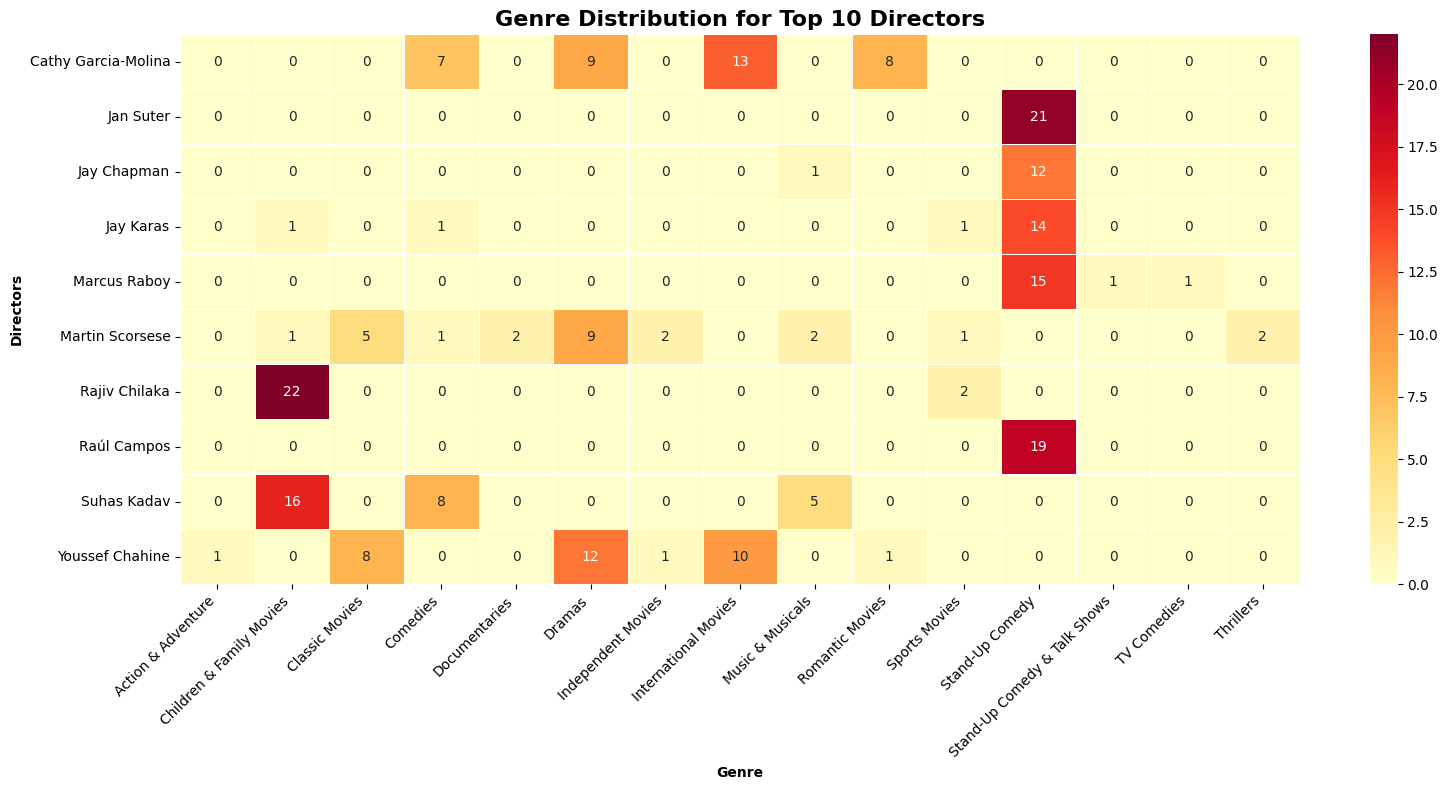

In [ ]:
# same logic for genre distribution for top cast and director
def plot_genre_distribution(exploded_df, group_col, top_series, group_label, cmap='YlOrRd'):
    top_names = top_series.index.tolist()
    filtered = exploded_df[exploded_df[group_col].isin(top_names)].sort_values(by=group_col)
    filtered_genres = filtered.explode('listed_in_list')

    grid = filtered_genres.pivot_table(
        index=group_col, columns='listed_in_list',
        values='title', aggfunc='count', fill_value=0
    )

    plt.figure(figsize=(16, 8))
    plt.title(f'Genre Distribution for Top 10 {group_label}', fontsize=16, fontweight='bold')
    sns.heatmap(grid, annot=True, fmt='d', cmap=cmap, linewidths=0.5)
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel(group_label, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



plot_genre_distribution(cast_exploded, 'cast_list', top_10_actors, 'cast')
plot_genre_distribution(director_exploded, 'director_list', top_10_directors, 'Directors')


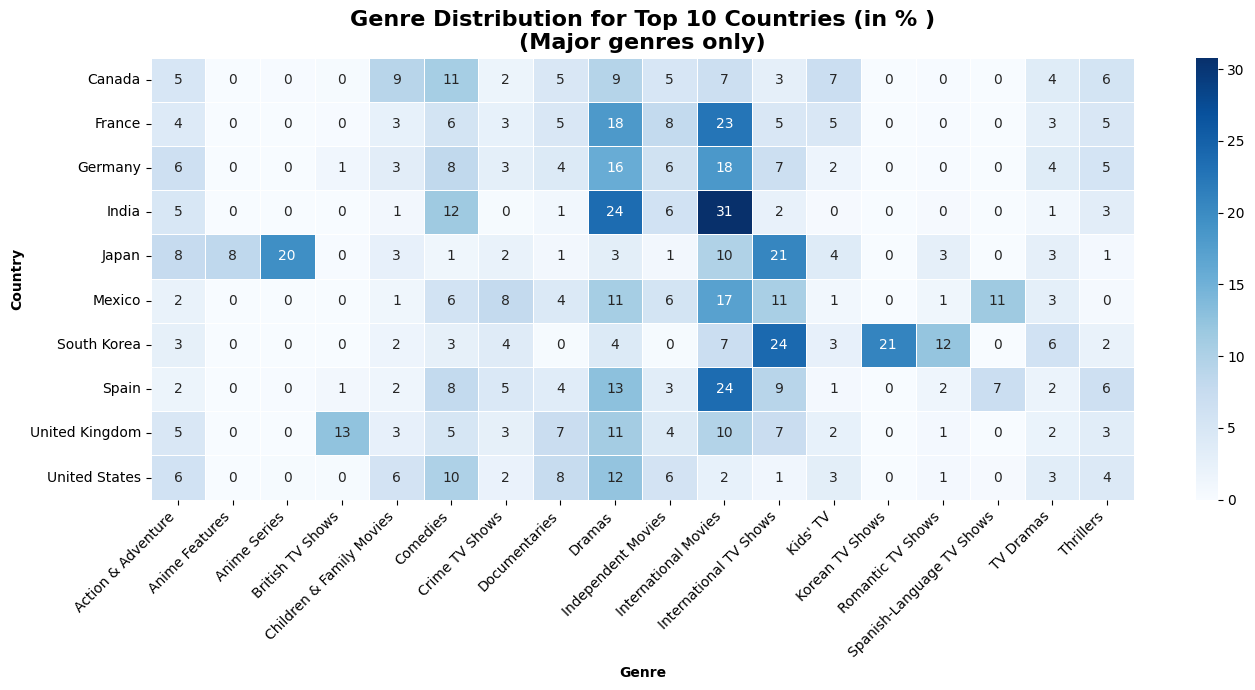

In [ ]:
top_country_names = top_10_country.index.tolist()
filtered = country_exploded[country_exploded['country_list'].isin(top_country_names)].sort_values(by='country_list')
filtered_genres = filtered.explode('listed_in_list')

grid = filtered_genres.pivot_table(index='country_list', columns='listed_in_list',values='title', aggfunc='count', fill_value=0)


grid_pct = grid.div(grid.sum(axis=1), axis=0) * 100

# to keep geners above 5% , to increse the readibility of heatmap
genres_to_keep = []
for genre in grid_pct.columns:
    if grid_pct[genre].max() > 5:
        genres_to_keep.append(genre)

grid_pct_clean = grid_pct[genres_to_keep]

plt.figure(figsize=(14, 7))
plt.title('Genre Distribution for Top 10 Countries (in % )\n(Major genres only)', fontsize=16, fontweight='bold')

sns.heatmap(grid_pct_clean, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)
plt.xlabel('Genre', fontweight='bold')
plt.ylabel('Country', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Text & Genre Analysis

listed_in_list
Dramas & International Movies                         362
Documentaries                                         359
Stand-Up Comedy                                       334
Comedies & Dramas & International Movies              274
Dramas & Independent Movies & International Movies    252
Kids' TV                                              220
Children & Family Movies                              215
Children & Family Movies & Comedies                   201
Documentaries & International Movies                  186
Dramas & International Movies & Romantic Movies       180
Name: count, dtype: int64


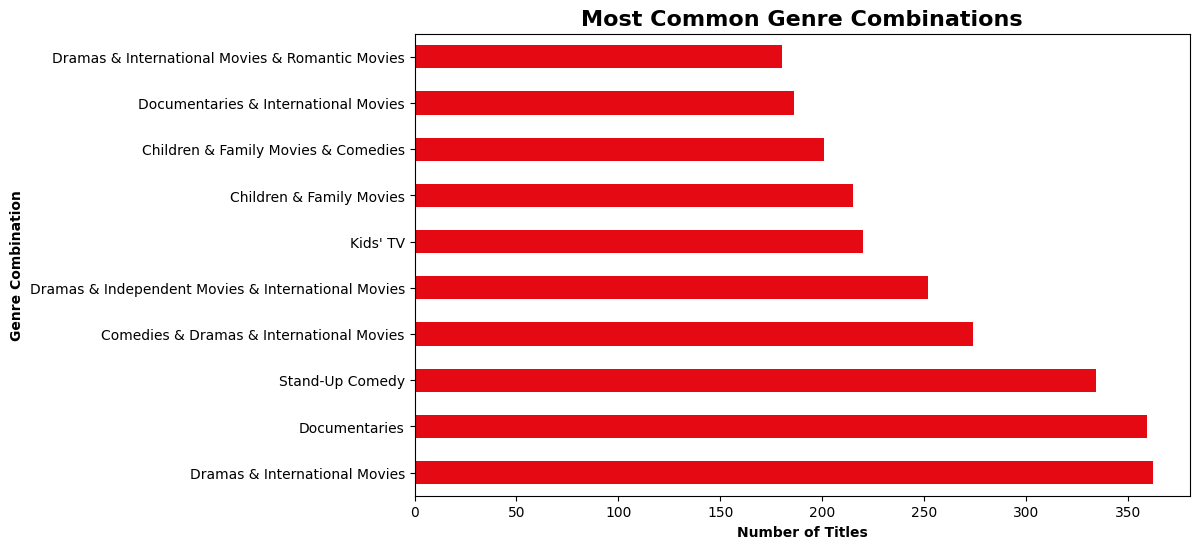

In [ ]:
genre_combo_counts = df['listed_in_list'].apply(lambda x: " & ".join(sorted(x))).value_counts().head(10)

print(genre_combo_counts)

plt.figure(figsize=(10, 6))
genre_combo_counts.plot(kind='barh', color='#E50914')
plt.title('Most Common Genre Combinations', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles' ,fontweight='bold')
plt.ylabel('Genre Combination',fontweight='bold')

plt.show()

In [ ]:
def mostly_used(genre_name, n=15):
    text = " ".join(df[df['listed_in'].str.contains(genre_name, na=False)]['description'])
    words = text.lower().split()

    commonly_used_words = ['their', 'after','about', 'while', 'where','these','those','other','young' ,'woman','friends' ,'family', 'stand-up']
                         # droping friends , family , young as they don't describe much about the genre and
                        #  especially stand-up as it's counting stand-up as different and comedy as different

    word_counts = {}
    for word in words:
        if len(word) > 4 and word not in commonly_used_words :   # skiping small common words like 'the', 'a', 'and' , and some commonly used words
            if word in word_counts:
                word_counts[word] = word_counts[word] + 1
            else:
                word_counts[word] = 1
    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:n]

horror_words = mostly_used('Horror')
comedy_words = mostly_used('Comed') # comed as 2 genre are here 'comedies' and 'stand up comedy'

print(horror_words)
print(comedy_words)

[('group', 34), ('mysterious', 32), ('horror', 28), ('finds', 25), ('supernatural', 25), ('begins', 21), ('spirit', 18), ('terrifying', 18), ('haunted', 18), ('couple', 17), ('takes', 17), ('series', 17), ('home,', 16), ('remote', 16), ('tries', 16)]
[('comedy', 124), ('comedian', 116), ('three', 112), ('takes', 111), ('finds', 92), ('school', 90), ('comic', 90), ('special', 68), ('world', 67), ('series', 63), ('lives', 60), ('father', 59), ('tries', 58), ('stage', 57), ('group', 56)]


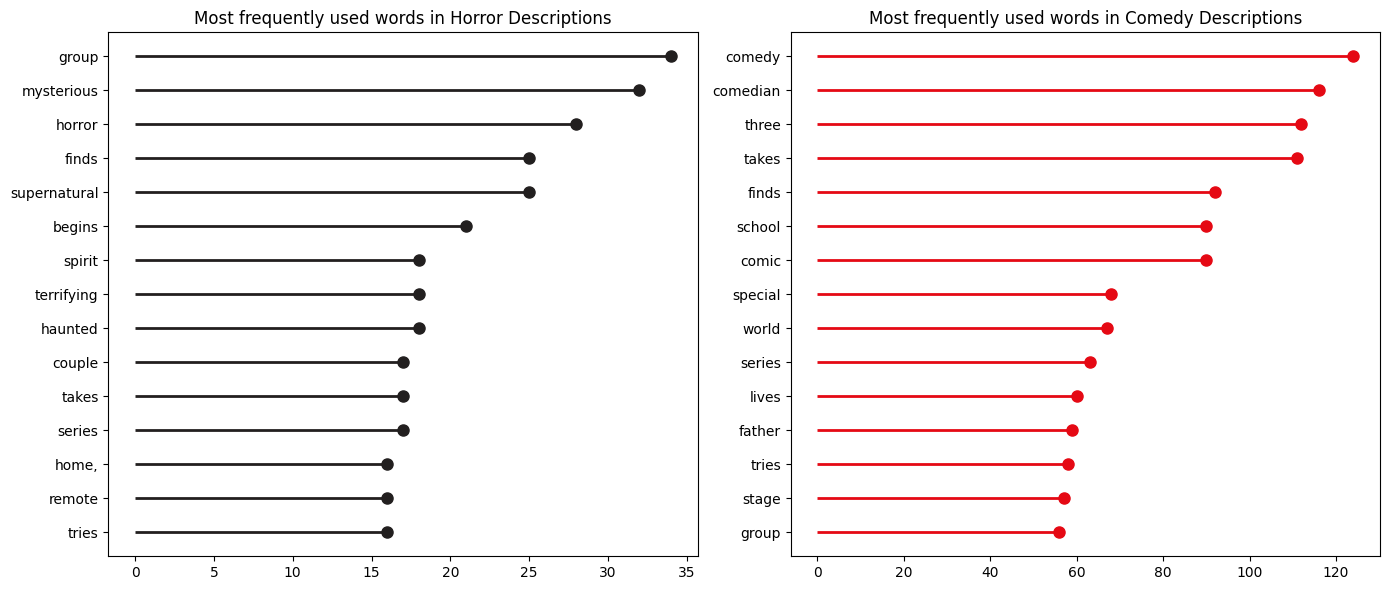

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# for horror
labels_horror = [w for w, c in horror_words]
values_horror = [c for w, c in horror_words]
axes[0].hlines(y=labels_horror, xmin=0, xmax=values_horror, color='#221f1f', linewidth=2)
axes[0].plot(values_horror, labels_horror, 'o', color='#221f1f', markersize=8)
axes[0].set_title('Most frequently used words in Horror Descriptions')
axes[0].invert_yaxis()

# for comedy
labels_c = [w for w, c in comedy_words]
values_c = [c for w, c in comedy_words]
axes[1].hlines(y=labels_c, xmin=0, xmax=values_c, color='#E50914', linewidth=2)
axes[1].plot(values_c, labels_c, 'o', color='#E50914', markersize=8)
axes[1].set_title('Most frequently used words in Comedy Descriptions')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()